In [2]:
import polars as pl
import duckdb 
import matplotlib.pyplot as plt 
import timeit
import traceback
import numpy as np
import dcor 
import pandas as pd

In [14]:
path = "C:/Users/Dhyla/Documents/2. FinanceStockDatabase/Finance_Stock_Database/data/stocks.db"
con = duckdb.connect(path, read_only = True)
FTCI_BAL = con.execute("SELECT * FROM BALANCESHEET_FTCI").pl()
con.close()

In [15]:
FTCI_BAL = FTCI_BAL.with_columns(pl.col(c).replace('None', None).cast(pl.Int32) for c in FTCI_BAL.columns if c not in ['DATE', 'reportedCurrency'])
FTCI_BAL

reportedCurrency,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,cashAndShortTermInvestments,inventory,currentNetReceivables,totalNonCurrentAssets,propertyPlantEquipment,accumulatedDepreciationAmortizationPPE,intangibleAssets,intangibleAssetsExcludingGoodwill,goodwill,investments,longTermInvestments,shortTermInvestments,otherCurrentAssets,otherNonCurrentAssets,totalLiabilities,totalCurrentLiabilities,currentAccountsPayable,deferredRevenue,currentDebt,shortTermDebt,totalNonCurrentLiabilities,capitalLeaseObligations,longTermDebt,currentLongTermDebt,longTermDebtNoncurrent,shortLongTermDebtTotal,otherCurrentLiabilities,otherNonCurrentLiabilities,totalShareholderEquity,treasuryStock,retainedEarnings,commonStock,commonStockSharesOutstanding,DATE
str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,date
"""USD""",null,7221000,-7221000,-7221000,null,null,-7221000,null,null,null,null,null,null,null,14442000,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-8445000,null,null,null,6881100,2020-03-31
"""USD""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,6881100,2020-06-30
"""USD""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,6881100,2020-09-30
"""USD""",71393000,64724999,33372999,33372999,5891000,23734000,6668000,null,null,null,null,null,null,1857000,null,1726998,null,63942000,59809000,17127000,null,null,1242000,4133000,null,784000,1000000,null,2381000,18460000,3349000,7451000,null,-42643000,1000,6881100,2020-12-31
"""USD""",72451000,63266000,5340000,5340000,4273000,43906000,9185000,null,null,null,null,null,null,1639000,1639000,9747000,null,71955000,68041000,30107000,null,null,28954000,3914000,null,null,null,null,null,29750000,3914000,496000,null,-50085000,1000,8216355,2021-03-31
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USD""",91693000,76226000,8255000,8255000,15124000,37345000,15467000,null,null,137000,137000,7421000,null,1273000,null,15502000,null,61285000,57346000,18742000,null,null,872000,3939000,1755000,null,null,null,1755000,32955000,3056000,30408000,null,-335506000,13000,12738029,2024-09-30
"""USD""",89928000,76128000,11247000,11247000,10144000,39709000,13800000,null,null,null,null,7139000,null,954000,null,15028000,null,70892000,49073000,12995000,null,null,755000,21819000,1166000,9466000,null,null,10632000,29692000,2422000,19036000,null,-347741000,1000,12787050,2024-12-31
"""USD""",84061000,71098000,5909000,5909000,6828000,44238000,12963000,null,null,null,null,7173000,null,842000,null,14123000,null,68533000,50898000,14636000,null,null,623000,17635000,967000,10169000,null,null,11136000,32890000,2206000,15528000,null,-351560000,1000,14588972,2025-03-31


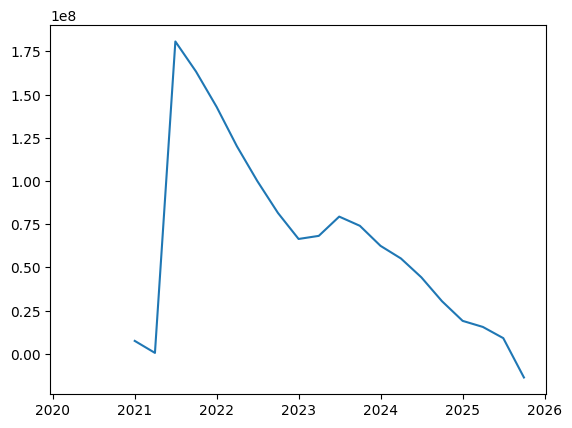

In [16]:
plt.plot(FTCI_BAL['DATE'].to_list(), FTCI_BAL['totalShareholderEquity'].to_list())
plt.show()

In [46]:
shareholdereq = FTCI_BAL.select('DATE', 'totalLiabilities', 'totalAssets')
shareholdereq.write_csv("data_proj5/ftcishareholdereq.csv")

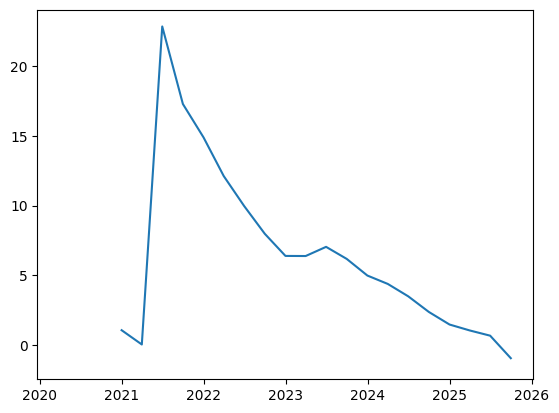

In [19]:
bookval = FTCI_BAL.with_columns('totalShareholderEquity', 'commonStockSharesOutstanding', book = pl.col('totalShareholderEquity') / pl.col('commonStockSharesOutstanding')).select('DATE','book', 'commonStockSharesOutstanding', 'totalShareholderEquity')
plt.plot(bookval['DATE'].to_list(), bookval['book'].to_list())
plt.show()

In [45]:
bookvalcon = bookval.select('DATE', 'book')
bookvalcon.write_csv("data_proj5/ftcibookval.csv")

In [30]:
path = "C:/Users/Dhyla/Documents/2. FinanceStockDatabase/Finance_Stock_Database/data/stocks.db"
con = duckdb.connect(path, read_only = True)
FTCI_CASH = con.execute("SELECT * FROM CASHFLOW_FTCI").pl()
con.close()

In [33]:
FTCI_CASH = FTCI_CASH.with_columns(pl.col(c).replace('None', None).cast(pl.Float32) for c in FTCI_CASH.columns if c not in ['DATE', 'reportedCurrency'])
FTCI_CASH

reportedCurrency,operatingCashflow,paymentsForOperatingActivities,proceedsFromOperatingActivities,changeInOperatingLiabilities,changeInOperatingAssets,depreciationDepletionAndAmortization,capitalExpenditures,changeInReceivables,changeInInventory,profitLoss,cashflowFromInvestment,cashflowFromFinancing,proceedsFromRepaymentsOfShortTermDebt,paymentsForRepurchaseOfCommonStock,paymentsForRepurchaseOfEquity,paymentsForRepurchaseOfPreferredStock,dividendPayout,dividendPayoutCommonStock,dividendPayoutPreferredStock,proceedsFromIssuanceOfCommonStock,proceedsFromIssuanceOfLongTermDebtAndCapitalSecuritiesNet,proceedsFromIssuanceOfPreferredStock,proceedsFromRepurchaseOfEquity,proceedsFromSaleOfTreasuryStock,changeInCashAndCashEquivalents,changeInExchangeRate,netIncome,DATE
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,date
"""USD""",-6.3e6,null,null,null,null,37000.0,85000.0,null,4.128e6,null,-85000.0,3e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,3.42e6,2020-03-31
"""USD""",-1.6615e7,null,null,null,null,3000.0,85000.0,null,-7000.0,null,-85000.0,-1.216e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-6.776e6,2020-06-30
"""USD""",8.277e6,null,null,null,null,3000.0,85000.0,null,-5.644e6,null,-85000.0,-2e6,null,null,null,null,null,null,null,null,null,null,0.0,null,null,null,-2.84e6,2020-09-30
"""USD""",1.4127e7,null,null,null,null,4000.0,256000.0,null,4.342e6,null,1.868e6,-3e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-9.728e6,2020-12-31
"""USD""",-2.5904e7,null,null,null,null,9000.0,85000.0,-2.023e7,-2.587e6,null,-85000.0,-2.045e6,null,null,null,null,null,null,null,null,null,null,39000.0,null,-2.8034e7,null,-7.442e6,2021-03-31
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USD""",-2.373e6,null,null,null,null,417000.0,224000.0,null,1.937e6,null,-224000.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-1.5359e7,2024-09-30
"""USD""",-1.6691e7,null,null,null,null,442000.0,290000.0,null,4.98e6,null,5.332e6,1.4495e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-1.2235e7,2024-12-31
"""USD""",-8.483e6,null,null,null,null,302000.0,83000.0,null,3.316e6,null,3.124e6,3000.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-3.819e6,2025-03-31


In [34]:
path = "C:/Users/Dhyla/Documents/2. FinanceStockDatabase/Finance_Stock_Database/data/stocks.db"
con = duckdb.connect(path, read_only = True)
FTCI_INC = con.execute("SELECT * FROM INCOMESTATEMENT_FTCI").pl()
con.close()

In [35]:
FTCI_INC = FTCI_INC.with_columns(pl.col(c).replace('None', None).cast(pl.Float32) for c in FTCI_INC.columns if c not in ['DATE', 'reportedCurrency'])
FTCI_INC

reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,investmentIncomeNet,netInterestIncome,interestIncome,interestExpense,nonInterestIncome,otherNonOperatingIncome,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome,DATE
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,date
"""USD""",6.98e6,3.2376e7,2.5396e7,2.5396e7,2.896e6,2.475e6,1.094e6,4.084e6,null,-112000.0,null,112000.0,null,null,null,37000.0,2.784e6,-158000.0,null,3.42e6,null,2.896e6,2.933e6,3.42e6,2020-03-31
"""USD""",-1.382e6,5.1157e7,5.2539e7,5.2539e7,-5.958e6,2.243e6,1.515e6,4.576e6,null,-121000.0,null,121000.0,null,null,null,3000.0,-6.757e6,19000.0,null,-6.776e6,null,-5.999e6,-5.996e6,-6.776e6,2020-06-30
"""USD""",2.866e6,5.964e7,5.6774e7,5.6774e7,-2.525e6,2.912e6,1.438e6,5.391e6,null,-70000.0,null,70000.0,null,null,null,3000.0,-2.816e6,24000.0,null,-2.84e6,null,-2.56e6,-2.557e6,-2.84e6,2020-09-30
"""USD""",-4.825e6,4.4179e7,4.9004e7,4.9004e7,-1.1339e7,4.168e6,1.175e6,6.514e6,null,-177000.0,null,177000.0,null,null,null,4000.0,-9.696e6,32000.0,null,-9.728e6,null,-1.1263e7,-1.1259e7,-9.728e6,2020-12-31
"""USD""",119000.0,6.5707e7,6.5588e7,6.5588e7,-8.019e6,5.084e6,1.954e6,8.138e6,null,-14000.0,null,14000.0,null,572000.0,null,9000.0,-7.243e6,-19000.0,null,-7.442e6,null,-7.447e6,-7.438e6,-7.442e6,2021-03-31
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USD""",-4.306e6,1.0136e7,1.4442e7,1.4442e7,-1.4976e7,6.797e6,1.467e6,1.067e7,null,24000.0,38000.0,24000.0,null,null,null,417000.0,-1.5115e7,244000.0,null,-1.5359e7,null,-1.4976e7,-1.4559e7,-1.5359e7,2024-09-30
"""USD""",-3.837e6,1.3202e7,1.7039e7,1.7039e7,-1.3428e7,6.066e6,1.474e6,9.591e6,null,-208000.0,null,208000.0,null,null,null,442000.0,-1.2303e7,-68000.0,null,-1.2235e7,null,-1.2095e7,-1.1653e7,-1.2235e7,2024-12-31
"""USD""",-3.447e6,2.0803e7,2.425e7,2.425e7,-1.056e7,5.053e6,924000.0,7.113e6,null,-705000.0,6000.0,711000.0,null,null,null,-6.284e6,-3.565e6,254000.0,null,-3.819e6,null,-4.276e6,-1.056e7,-3.819e6,2025-03-31


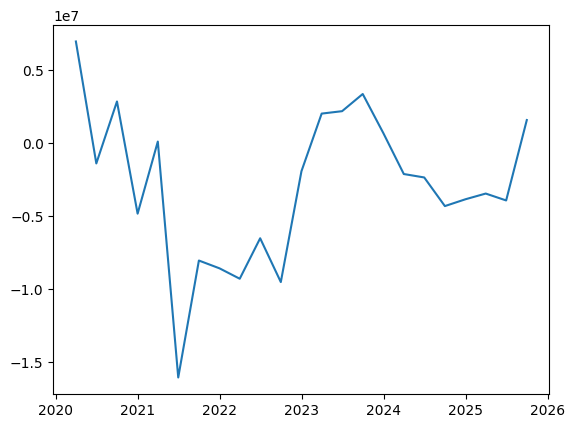

In [37]:
revenue = FTCI_INC.select('DATE','grossProfit', 'totalRevenue', 'costOfRevenue')
plt.plot(revenue['DATE'].to_list(), revenue['grossProfit'].to_list())
plt.show()

In [43]:
path = "C:/Users/Dhyla/Documents/2. FinanceStockDatabase/Finance_Stock_Database/data/stocks.db"
con = duckdb.connect(path, read_only = True)
FTCI_DAILY = con.execute("SELECT * FROM TICKER_FTCI").pl()
FTCI_DAILY = FTCI_DAILY.with_columns(DATE = pl.col('date').str.strptime(pl.Date, "%Y-%m-%d")).drop('date')
FTCI_DAILY
con.close()

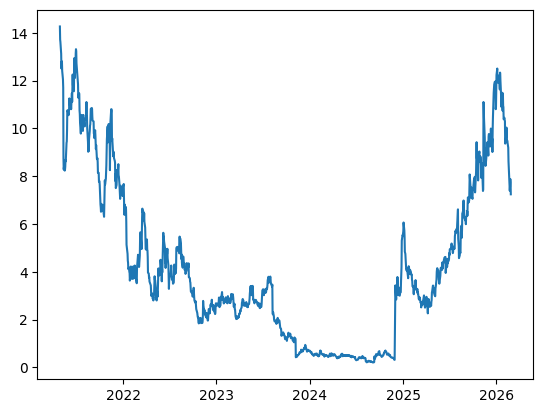

In [44]:
plt.plot(FTCI_DAILY['DATE'].to_list(), FTCI_DAILY['close'].to_list())
plt.show()

In [58]:
from datetime import datetime, timedelta
FTCI_DAILY_CLOSE = FTCI_DAILY.select('DATE', 'close')
FTCI_DAILY_DICT = FTCI_DAILY_CLOSE.rows_by_key(key='DATE')
pbls = []
for row in bookval.iter_rows():
    date = row[0]
    if date in list(FTCI_DAILY['DATE']):
        stockprice = FTCI_DAILY_DICT[date][0][0]
        item = {'DATE': date, 'book': row[1], 'market':stockprice}
        pbls.append(item)
    elif date >= min(FTCI_DAILY_CLOSE['DATE']) and date<=max(FTCI_DAILY_CLOSE['DATE']):
        for i in range(0,5):
            try:
                daybefore = date - timedelta(days = i)
                if daybefore in list(FTCI_DAILY['DATE']):
                    stockprice = FTCI_DAILY_DICT[daybefore][0][0]
                    item = {'DATE': date, 'book': row[1], 'market':stockprice}
                    pbls.append(item)
                    break
                else:
                    continue
            except:
                print("error")

    else:
        print("no match possible")
pb = pl.DataFrame(pbls)
pbready = pb.with_columns(
    (pl.col('market')/ pl.col('book')).alias('pbratio')
                    )
pbready = (
    pbready
    .with_columns(
        pl.when(pl.col("pbratio") < 0)
          .then(100)
          .otherwise(pl.col("pbratio"))
          .alias("pbratio")
    )
    .select("DATE", "pbratio")
)

pbready.write_csv("data_proj5/ftcipbval.csv")


no match possible
no match possible
no match possible
no match possible
no match possible
